# Additional Stuff Sofie suggested

* whole cortex analysis either using eccentricity (sqrt(G1^2 + G2^2 + G3^2)) and then group model
* post hoc per gradient
* maybe for 'general' idea you could also compute degree centrality. Eg. take connectivity matrix > take top 10%, binarize and sum the columns so all regions have a DC value

In [2]:
import numpy as np
import nibabel as nib
import os.path as op
import os

from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import seaborn as sns
from brainspace.utils.parcellation import map_to_labels
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap

pval_cmap = get_pval_colormap()
views = ['medial','lateral','dorsal','posterior']

import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

from os import listdir
subList = [f'{int(sub):02d}' for sub in range(1, 67)]

fsaverage = fetch_surf_fsaverage('fsaverage5') 

# add group info
bids_folder_orig = '/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()

In [3]:
from utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]


In [4]:
confspec='36P'
frames_per_run_thresh=104
scrub_thresh=0.3

confspec += f'scrub{str(scrub_thresh)[2]}'  #if scrubbing else confspec
confspec += 'BPfilter' #if bp_filtering else confspec
confspec += f'runFD{str(frames_per_run_thresh)}' #if run_FD_filter else confspec
print(confspec)

## load in gradients

n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder, 'derivatives', f'gradients.{confspec}', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])


36Pscrub3BPfilterrunFD104


In [5]:
dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [6]:
# Eccentricity
measure_type = 'Eccentricity'

df_eccentricities = []
for sub in range(1,67):
    tmp = df_gms.xs(sub,0,'subject').droplevel('group')
    #eccentricity = np.sqrt(tmp.xs(1,0,'n_gradient')**2 + tmp.xs(2,0,'n_gradient')**2 + tmp.xs(3,0,'n_gradient')**2)
    eccentricity = np.sqrt(tmp.loc[1]**2 + tmp.loc[2]**2 + tmp.loc[3]**2) # only n_grad left as index
    df_eccentricities.append(eccentricity) # group level still in index

df_eccentricities = pd.DataFrame(df_eccentricities, index=sub_array)
df_eccentricities.index.name = 'subject'
df_eccentricities = df_eccentricities.join(group_list).set_index('group', append=True)



In [7]:
measure_type = 'Eccentricity'
tmp = df_eccentricities


In [57]:
# Grad loading

n_grad = 3
measure_type = f'Grad-{n_grad} loading'
tmp = df_gms.xs(n_grad,0,'n_gradient')

In [8]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

group_0 = tmp.xs(0,0,'group')
group_1 = tmp.xs(1,0,'group')

t_stats, p_values = ttest_ind(group_0, group_1, axis=0, equal_var=False)
corrected_p_values = multipletests(p_values, method='fdr_bh')[1] 
print(len(p_values))

20484


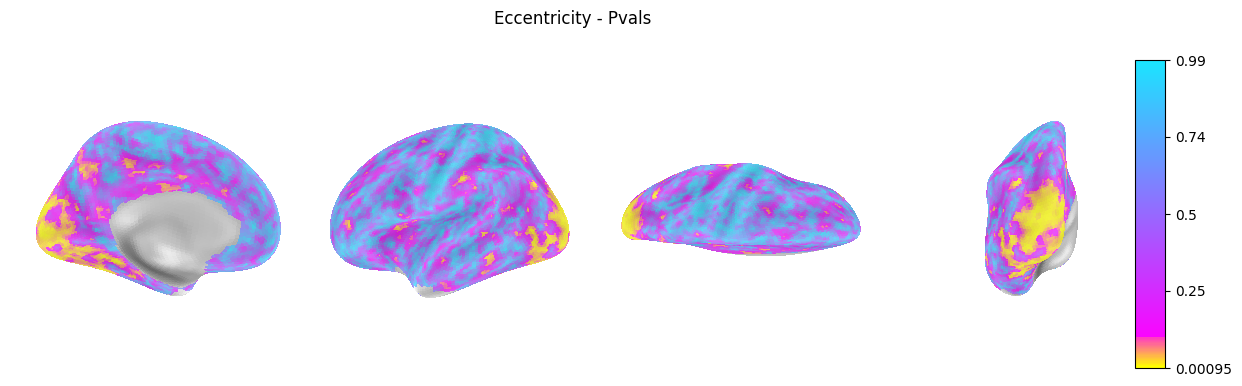

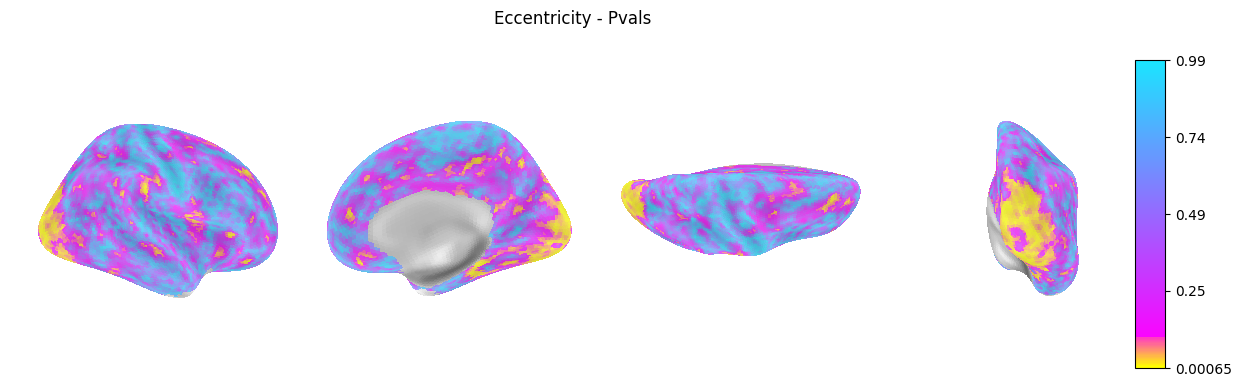

In [9]:
#if resolution == 'parcel':
#    stats_fsav5 = map_to_labels(p_values, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex
#else:
stats_fsav5 = p_values

for i, hemi in enumerate(['L','R']):
    map = np.split(stats_fsav5,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=pval_cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{measure_type} - Pvals', y=0.75)

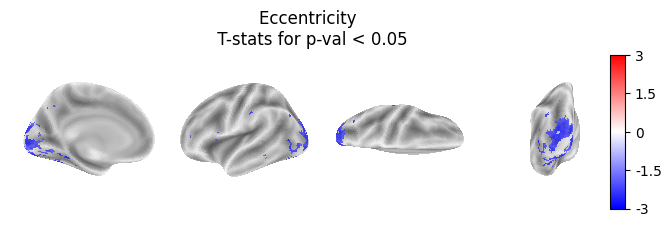

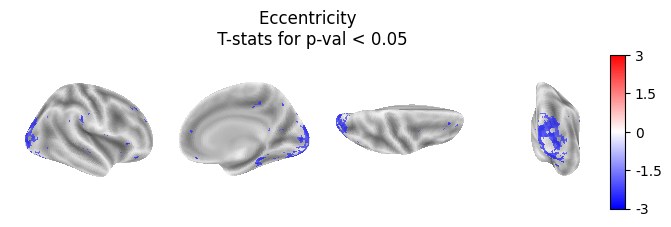

In [10]:
tstat_cmap = 'bwr'
views = ['medial','lateral','dorsal','posterior']
thresh= 0.05

stats_fsav5 = t_stats
stats_fsav5[p_values > thresh] = np.nan

for i, hemi in enumerate(['L','R']):
    map = np.split(stats_fsav5,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (8,4), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, vmin=-3, vmax=3,
                view= view,cmap=tstat_cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{measure_type} \n T-stats for p-val < {thresh}', y=0.8)

# observed: late IPS is further to DMN/motor end whereas visual closer to visual in Dyscalculics


## Degree Centrality
take connectivity matrix > take top 10%, binarize and sum the columns so all regions have a DC value

In [ ]:
confspec = '32Pscrub3BPfilter'
only_top10 = True
top_n = 36 # top 10% of 360 connections

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
# outliers for GMs-aligend ~ for 32P: sub-6; for 36P: sub-64
#subList.remove('64') if confspec == '36Pscrub3BPfilter' else subList.remove('06') 
sub_array = np.array([int(i) for i in subList])

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.parcel')


In [ ]:
sub = '01'
cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
cm = np.load(cm_file)

cm_c = np.zeros_like(cm)
for ii,row in enumerate(cm): 
    top_10_ind = np.argsort(row)[-top_n:][::-1] # argsort returns indices of sorted array in ascending order, [-top_n:] takees therefore the top (here=last) 36, [::-1] reverses the array
    cm_c[ii, top_10_ind] = 1 #row[top_10_ind]


In [37]:
cm_c[359, :]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [39]:
cm_c.sum(axis=0) # sum over rows, i.e. columns of the correlation matrix

array([57., 32., 30., 74., 65., 54., 23., 45., 37., 45., 63., 41., 68.,
       16.,  9., 28., 42., 45., 55., 46., 39., 23., 38., 34., 33., 37.,
       42., 36., 32., 38., 18., 22., 29., 41., 46., 23., 45., 28., 23.,
       42., 50., 21., 53., 49., 40., 58., 34., 20., 17., 47., 37., 39.,
       47., 22., 30., 52., 16., 10., 21., 28., 35., 56., 47., 32., 45.,
       29., 43., 48., 75., 56., 51., 61., 38., 49., 39., 40., 47., 52.,
       25., 22., 35., 43., 33., 44., 39., 43., 38., 62., 32., 38., 40.,
       39., 30., 34., 73., 64., 56., 35., 39., 37., 36., 13., 64., 16.,
       26., 31., 12., 51., 45.,  9., 31., 11., 42., 19., 16., 40., 53.,
       14., 28.,  6., 46., 23.,  9., 44., 32., 41., 45., 12., 39., 46.,
       58., 65., 26., 43., 38., 17., 72., 60., 44., 50., 30., 30., 28.,
       36., 56., 60., 24., 68., 44., 66., 68., 23., 35., 35., 37., 53.,
       47., 60., 50., 22., 47., 45., 53., 28., 18., 23., 31., 16., 37.,
       60., 20., 28., 61., 48., 54., 49., 42., 10., 36., 39., 53

In [ ]:
DCs= [None] * len(subList)

for i,sub in enumerate(subList):
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
    cm = np.load(cm_file)
    #if only_top10:
    cm_c = np.zeros_like(cm)
    for ii,row in enumerate(cm): 
        top_10_ind = np.argsort(row)[-top_n:][::-1] # argsort returns indices of sorted array in ascending order, [-top_n:] takees therefore the top (here=last) 36, [::-1] reverses the array
        cm_c[ii, top_10_ind] = 1 #row[top_10_ind]
    DCs[i] = cm_c.sum(axis=0)

DCs = np.array(DCs)
np.shape(DCs)

(66, 360)

Text(0.5, 0.75, 'Mean Degree Centrality')

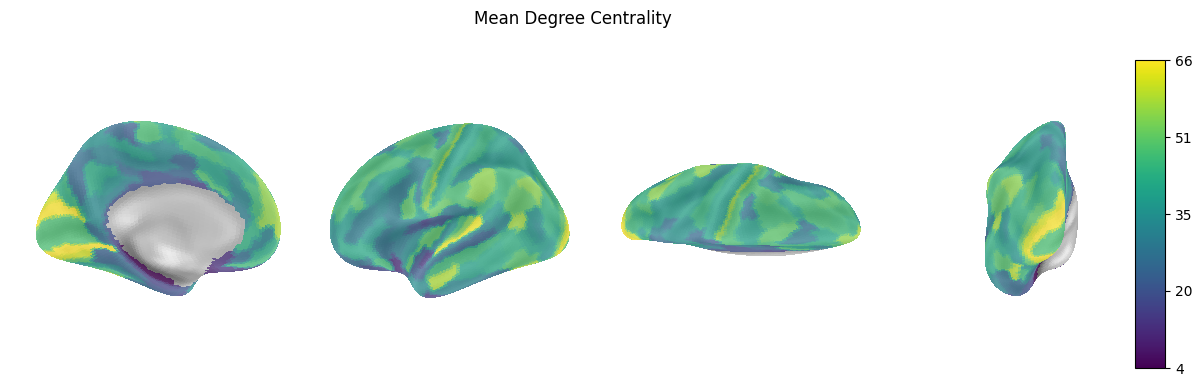

In [25]:
mean_DCs = np.mean(DCs, axis=0)

mean_DCs_fsav5 = map_to_labels(mean_DCs, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex

i, hemi= 0, 'L'
surf_map = np.split(mean_DCs_fsav5,2)[i]
cmap = 'viridis'
surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left
figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'posterior' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map, #vmin = 18, vmax= 25,
            view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)
figure.suptitle(f'Mean Degree Centrality', y=0.75)


test between groups

In [40]:
measure_type = 'Degree Centrality (DC)'

df_DCs = pd.DataFrame(DCs, index=sub_array)
df_DCs.index.name = 'subject'
df_DCs = df_DCs.join(group_list).set_index('group', append=True)

tmp = df_DCs.copy()



In [41]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

group_0 = tmp.xs(0,0,'group')
group_1 = tmp.xs(1,0,'group')

t_stats, p_values = ttest_ind(group_0, group_1, axis=0, equal_var=False)
corrected_p_values = multipletests(p_values, method='fdr_bh')[1] 
print(len(p_values))

360


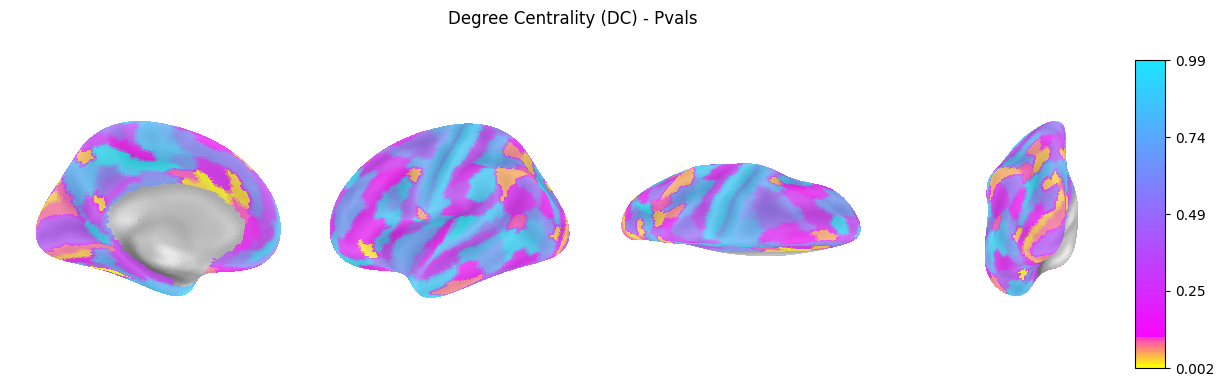

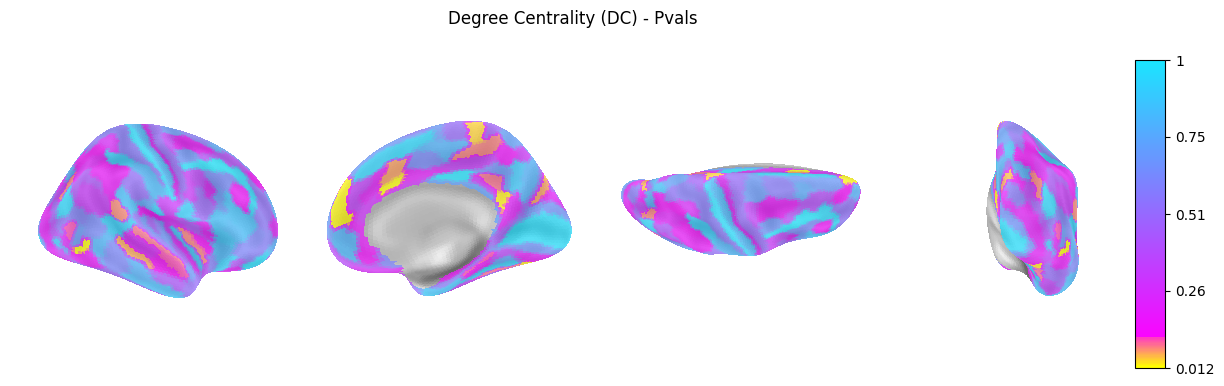

In [42]:
#if resolution == 'parcel':
stats_fsav5 = map_to_labels(p_values, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex
#else:
#stats_fsav5 = p_values

for i, hemi in enumerate(['L','R']):
    map = np.split(stats_fsav5,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=pval_cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{measure_type} - Pvals', y=0.75)

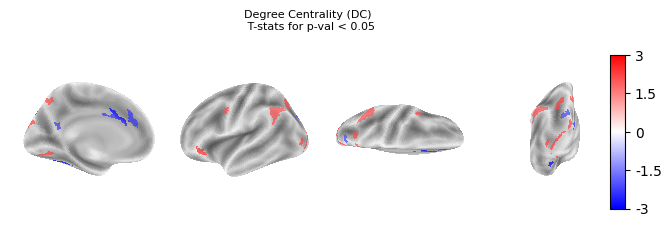

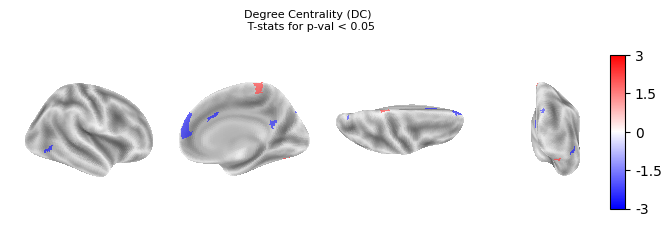

In [43]:
tstat_cmap = 'bwr'
views = ['medial','lateral','dorsal','posterior']
thresh= 0.05

#stats_fsav5 = t_stats
t_stats_fil = t_stats.copy()
t_stats_fil[p_values > thresh] = np.nan
stats_fsav5 = map_to_labels(t_stats_fil, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex

for i, hemi in enumerate(['L','R']):
    map = np.split(stats_fsav5,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (8,4), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, vmin=-3, vmax=3,
                view= view,cmap=tstat_cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{measure_type} \n T-stats for p-val < {thresh}', y=0.8, fontsize=8)
